# DIANYA Hackathon
## This notebook includes the executables blocks of code that we used to train our model. 

Clinical data was sourced in MIMIC III database.
Clinical factors were spoted by a team of physicians.



In [1]:
## This cell establishes our foundational libraries and loads the raw dataset into memory. 

import pandas as pd
import numpy as np
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, accuracy_score
import xgboost as xgb

print("--- Loading the Tidy Dataset ---")
df = pd.read_csv("main.csv")
print(f"Total Patients Loaded: {len(df)}")

--- Loading the Tidy Dataset ---
Total Patients Loaded: 2975


In [2]:
print("--- Matrix Separation & Scrubbing ---")
clinical_features = [
    'age', 'ast', 'alt', 'ast_alt_ratio', 'bilirubin', 
    'albumin', 'platelets', 'inr', 'creatinine', 'glucose'
]

# Upgraded Scrubbing Loop
for col in clinical_features:
    # Step 1: Force the column to be treated as strings temporarily
    df[col] = df[col].astype(str)
    
    # Step 2: Use Regex to delete '[' and ']' characters 
    # (The backslashes are escape characters because brackets usually mean something special in code)
    df[col] = df[col].str.replace(r'\[|\]', '', regex=True)
    
    # Step 3: Now that the brackets are gone, safely convert to numbers!
    df[col] = pd.to_numeric(df[col], errors='coerce')

print("Data types successfully scrubbed and brackets eliminated.")

--- Matrix Separation & Scrubbing ---
Data types successfully scrubbed and brackets eliminated.


now that we loaded, scrubed and  

In [3]:
##By isolating the filtering step, you can easily tweak the 0.25 threshold later to see how stricter or looser data quality requirements affect your model's final accuracy.

print("--- Patient Filtering ---")
# Calculate missingness percentage row-by-row
missing_ratio_per_row = df[clinical_features].isnull().mean(axis=1)

# Drop any patient missing more than 25% of their lab results
df_filtered = df[missing_ratio_per_row <= 0.25].copy()

rows_dropped = len(df) - len(df_filtered)
print(f"Patients dropped (>25% missing labs): {rows_dropped}")
print(f"Viable Patients Remaining: {len(df_filtered)}")

--- Patient Filtering ---
Patients dropped (>25% missing labs): 0
Viable Patients Remaining: 2975


### Now that we got what we wanted (except for the fib-4 score) we move to creating our model

In [4]:
print("--- MICE Imputation ---")
# Initialize the iterative imputer to predict missing lab values
mice_imputer = IterativeImputer(max_iter=10, random_state=42)

df_imputed = df_filtered.copy()
df_imputed[clinical_features] = mice_imputer.fit_transform(df_filtered[clinical_features])

print("Imputation complete. Zero missing values in clinical features.")

--- MICE Imputation ---
Imputation complete. Zero missing values in clinical features.


This is the most computationally expensive step of the data prep phase. Isolating this means once it finishes running, the imputed matrix is locked in memory, and you won't have to wait for it to recalculate if you are just experimenting with XGBoost parameters in a later cell.

In [5]:
print("--- Feature Engineering (Post-Imputation) ---")
# Calculate the FIB-4 index using the fully imputed age, AST, ALT, and platelets
denominator = df_imputed['platelets'] * np.sqrt(df_imputed['alt'])
df_imputed['FIB4_score_calculated'] = (df_imputed['age'] * df_imputed['ast']) / denominator

# Update our feature list to include the newly minted score
features_to_check = clinical_features + ['FIB4_score_calculated']
print("Derived features successfully calculated and appended.")

--- Feature Engineering (Post-Imputation) ---
Derived features successfully calculated and appended.


With a mathematically complete dataset, we can securely derive complex medical scores. Calculating FIB-4 is isolated here so you can easily add other derived features (like the AST/Platelet Ratio Index) in the future without disrupting the rest of the pipeline.

In [6]:
print("--- Feature Engineering (Post-Imputation) ---")
# Calculate the FIB-4 index using the fully imputed age, AST, ALT, and platelets
denominator = df_imputed['platelets'] * np.sqrt(df_imputed['alt'])
df_imputed['FIB4_score_calculated'] = (df_imputed['age'] * df_imputed['ast']) / denominator

# Update our feature list to include the newly minted score
features_to_check = clinical_features + ['FIB4_score_calculated']
print("Derived features successfully calculated and appended.")

--- Feature Engineering (Post-Imputation) ---
Derived features successfully calculated and appended.


In [7]:
from sklearn.model_selection import GroupShuffleSplit

print("--- Prepping Binary Target Variable & Splitting Data ---")
X = df_imputed[features_to_check].copy()

# THE FIX: Binary Target Engineering
# We mathematically flag MASH_NAFLD as 1, and every other disease as 0.
y_binary = (df_filtered['liver_group'] == 'MASH_NAFLD').astype(int)

# Isolate the subject_ids to prevent data leakage
groups = df_filtered['subject_id'].copy()

print(f"Total MASH patients (1): {y_binary.sum()}")
print(f"Total Other patients (0): {len(y_binary) - y_binary.sum()}")

# The Group-Aware Splitter
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y_binary, groups=groups))

X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y_binary.iloc[train_idx], y_binary.iloc[test_idx]

print(f"\nTraining set: {len(X_train)} admissions.")
print(f"Testing set: {len(X_test)} admissions.")

--- Prepping Binary Target Variable & Splitting Data ---
Total MASH patients (1): 203
Total Other patients (0): 2772

Training set: 2381 admissions.
Testing set: 594 admissions.


This is your experimentation sandbox. Because everything above is already processed and sitting in memory, you can re-run this single cell in seconds to test different max_depth or learning_rate values to optimize your results

In [8]:
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score
import xgboost as xgb

print("--- Training the Binary XGBoost Model ---")

# Calculate the imbalance ratio to penalize the model for missing MASH
neg_cases = (y_train == 0).sum()
pos_cases = (y_train == 1).sum()
imbalance_weight = neg_cases / pos_cases

# Initialize the algorithm optimized for our specific binary problem
xgb_model = xgb.XGBClassifier(
    n_estimators=150,      
    learning_rate=0.05,    
    max_depth=4,           
    base_score=0.5,        # <-- THIS IS THE CRITICAL FIX!
    scale_pos_weight=imbalance_weight, 
    tree_method='hist',    
    random_state=42
)

# Train the model
xgb_model.fit(X_train, y_train)
print("Training Complete!\n")

print("--- The Final Exam (Evaluation) ---")
y_pred = xgb_model.predict(X_test)
y_pred_proba = xgb_model.predict_proba(X_test)[:, 1] 

roc_auc = roc_auc_score(y_test, y_pred_proba)

print(f"Overall Accuracy: {accuracy_score(y_test, y_pred) * 100:.2f}%")
print(f"ROC AUC Score: {roc_auc:.3f} (1.0 is perfect, 0.5 is random guessing)\n")

print("Detailed Diagnostic Report:")
print(classification_report(y_test, y_pred, target_names=['Other (0)', 'MASH-CKM (1)']))

--- Training the Binary XGBoost Model ---
Training Complete!

--- The Final Exam (Evaluation) ---
Overall Accuracy: 85.35%
ROC AUC Score: 0.743 (1.0 is perfect, 0.5 is random guessing)

Detailed Diagnostic Report:
              precision    recall  f1-score   support

   Other (0)       0.95      0.89      0.92       554
MASH-CKM (1)       0.19      0.38      0.26        40

    accuracy                           0.85       594
   macro avg       0.57      0.63      0.59       594
weighted avg       0.90      0.85      0.87       594



--- Generating Clinical Feature Importance (Native) ---


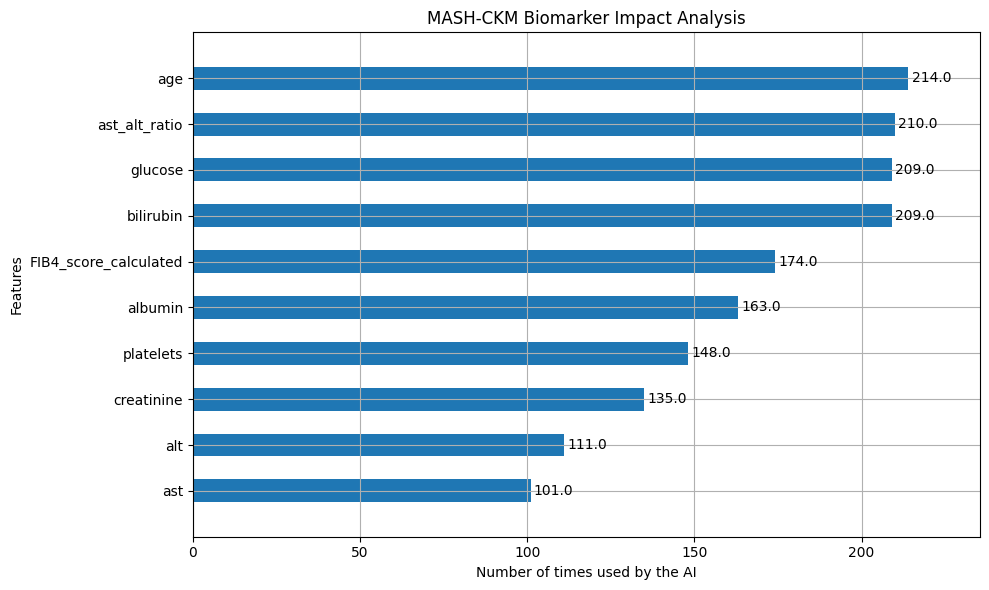

In [9]:
import matplotlib.pyplot as plt
import xgboost as xgb

print("--- Generating Clinical Feature Importance (Native) ---")
# XGBoost's built-in explainer
# importance_type='weight' counts how many times a feature was used to make a clinical decision
ax = xgb.plot_importance(
    xgb_model, 
    importance_type='weight',
    title='MASH-CKM Biomarker Impact Analysis',
    xlabel='Number of times used by the AI',
    max_num_features=10, # Show the top 10
    height=0.5
)

# Make the graph larger and easier to read
fig = ax.figure
fig.set_size_inches(10, 6)
plt.tight_layout()
plt.show()